In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy.integrate import odeint
import h5py

In [2]:
# sp.integrate.odeint

In [3]:
Nt=8

In [4]:
nbetas = {
    '0p2000':9,
    '0p3000':8,
    '0p4000':8
}

In [5]:
# Ns=32

# # mass="0p1000"
# # ibeta_m = 0
# # ibeta_M = 830

# mass="0p2000"
# ibeta_m = 775
# ibeta_M = 816
# nbeta = 9


# mass="0p3000"
# ibeta_m = 300
# ibeta_M = 700

# mass="0p4000"
# ibeta_m = 400
# ibeta_M = 1000

In [32]:
Ns=32

# v16 (32c). UNCOMMENT ONE mass block, run top-to-bottom, then switch masses. ibeta_m/ibeta_M bracket
# the mean Tc (argmin (VA-VB)^2 on the mean Veff). v16 mean Tc: m0.4=841, m0.3=500, m0.2=793.
# NOTE m0.2: VA-VB crosses zero at 793 with genuine (but narrow, dwidth~0.095) wells near Tc -- so do
# NOT apply a |xB-xA| double-well cut here; the plain argmin over the bracket is correct.

mass="0p4000"
ibeta_m = 816
ibeta_M = 866

mass="0p3000"
ibeta_m = 475
ibeta_M = 525

mass="0p2000"
ibeta_m = 760
ibeta_M = 810

In [33]:
# Ns=16

# # mass="0.1"
# # ibeta_m = 0
# # ibeta_M = 830

# # mass="0.2"
# # ibeta_m = 250
# # ibeta_M = 350

# # mass="0.3"
# # ibeta_m = 0
# # ibeta_M = 200

# mass="0.4"
# ibeta_m = 100
# ibeta_M = 300

In [34]:
ibetas=np.arange(0, 1001)

In [35]:
directory = "fit_params_"+str(Ns)+"c_m"+mass+"/"
directory2 = "/mnt/hdd_barracuda/llnl/reweight/data/"+str(Ns)+"b_v16/"
# v16 realaxis: central row iby=39 (nptsy=80); iby0 doesn't exist. betas grid is identical in any meas.bin.
f = h5py.File(directory2+"/m"+mass+"avghist_ibx"+str(0)+"_iby"+str(39)+"_nojkmeas.bin", 'r')
betas = f['beta'][()]
f.close()

In [36]:
lis_=[]

for ibeta in ibetas:
    f = h5py.File(directory+"/Veff.h5", 'r')
    print(f)
    tmp = f[str(ibeta)+'/minima_data'][()]
    f.close()
    # tmp = np.loadtxt( directory+"minima_data_"+str(ibeta)+".dat" )
    lis_.append(tmp)

lis = np.array(lis_)

<HDF5 file "Veff.h5" (mode r)>
<HDF5 file "Veff.h5" (mode r)>
<HDF5 file "Veff.h5" (mode r)>
<HDF5 file "Veff.h5" (mode r)>
<HDF5 file "Veff.h5" (mode r)>
<HDF5 file "Veff.h5" (mode r)>
<HDF5 file "Veff.h5" (mode r)>
<HDF5 file "Veff.h5" (mode r)>
<HDF5 file "Veff.h5" (mode r)>
<HDF5 file "Veff.h5" (mode r)>
<HDF5 file "Veff.h5" (mode r)>
<HDF5 file "Veff.h5" (mode r)>
<HDF5 file "Veff.h5" (mode r)>
<HDF5 file "Veff.h5" (mode r)>
<HDF5 file "Veff.h5" (mode r)>
<HDF5 file "Veff.h5" (mode r)>
<HDF5 file "Veff.h5" (mode r)>
<HDF5 file "Veff.h5" (mode r)>
<HDF5 file "Veff.h5" (mode r)>
<HDF5 file "Veff.h5" (mode r)>
<HDF5 file "Veff.h5" (mode r)>
<HDF5 file "Veff.h5" (mode r)>
<HDF5 file "Veff.h5" (mode r)>
<HDF5 file "Veff.h5" (mode r)>
<HDF5 file "Veff.h5" (mode r)>
<HDF5 file "Veff.h5" (mode r)>
<HDF5 file "Veff.h5" (mode r)>
<HDF5 file "Veff.h5" (mode r)>
<HDF5 file "Veff.h5" (mode r)>
<HDF5 file "Veff.h5" (mode r)>
<HDF5 file "Veff.h5" (mode r)>
<HDF5 file "Veff.h5" (mode r)>
<HDF5 fi

In [37]:
ibetac = np.argmin( ( (lis.T[2]- lis.T[3])**2 )[ibeta_m:ibeta_M] ) + ibeta_m

In [38]:
lis

array([[ 0.04261498,  0.04261498, -0.06524346, -0.06524346],
       [ 0.04258146,  0.04258146, -0.06536539, -0.06536539],
       [ 0.04254793,  0.04254793, -0.06548809, -0.06548809],
       ...,
       [ 0.28321276,  0.28321276, -0.08425785, -0.08425785],
       [ 0.28355225,  0.28355225, -0.08427849, -0.08427849],
       [ 0.28388978,  0.28388978, -0.08429914, -0.08429914]],
      shape=(1001, 4))

In [39]:
np.argmin( (betas-10.945)**2 )

np.int64(300)

In [40]:
np.argmin(betas-10.945)

np.int64(0)

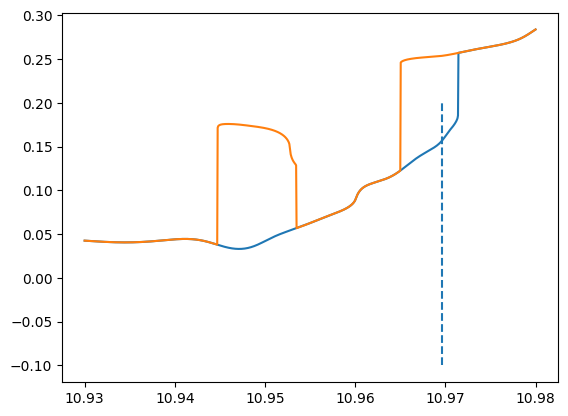

In [41]:
plt.plot( betas, lis.T[0])
plt.plot( betas, lis.T[1] )
plt.vlines( (betas[ibetac]), -0.1, 0.2, ls='dashed' )

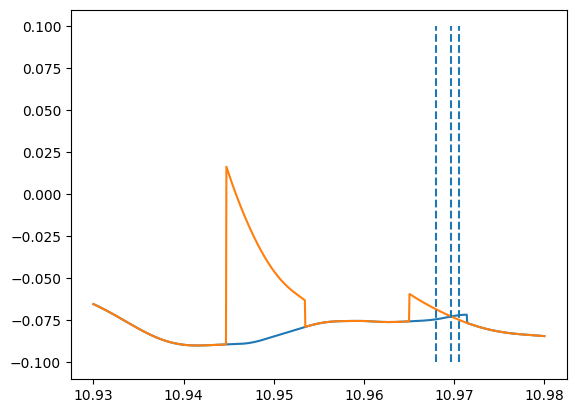

In [42]:
plt.plot( betas, lis.T[2])
plt.plot( betas, lis.T[3] )
plt.vlines( (betas[ibeta_m], betas[ibeta_M]), -0.1, 0.1, ls='dashed' )
plt.vlines( (betas[ibetac]), -0.1, 0.1, ls='dashed' )

In [43]:
ibeta_m, ibetac, ibeta_M

(760, np.int64(793), 810)

In [44]:
np.savetxt( "betac_ibetac_mass"+mass+"_"+str(Ns)+".dat", [betas[ibetac], ibetac] )
np.savetxt( "betas_mass"+mass+"_"+str(Ns)+".dat", betas )
# np.savetxt( "minima_data_mass"+mass+"_"+str(Ns)+".dat", lis )